
## Pedro Sáez Díaz

# **A. The $\beta$-method for a scalar IVP**

In [ ]:
# import all the packages here

import numpy as np
import matplotlib.pyplot as plt
import warnings


In [ ]:
# Performs integration for the linear IVP given by
#           d/dt u = lambda * u + g(t), u(t_0) = u_0
# using the beta-method
#
# INPUT
# lambda        constant defining the rhs
# g             function defining time-depdendent part of rhs
# tRange        the time interval [t_0, T] of integration
# u0            initial solution at t = tRange(1) (N x 1 array)
# beta          defines the method
# h             the step-size
#
# OUTPUT
# tArray        array containing the time points
# solArray      array containing the solution at each time point
#               (the ith row equals the solution at time tArray(i))

def LinearBetaMethod(Lambda, g, tRange, u0, beta, h):

    #Initialize the output based on the number of time steps and on the size
    #of the initial condition
    #The initial condition is saved in the first row of solArray
    dimension_m = len(u0)
    numtime_steps = int((tRange[1]-tRange[0])/h)
    solArray = np.zeros((numtime_steps+1, dimension_m))
    solArray[0] = u0
    tArray = np.zeros(numtime_steps+1)
    tArray[0] = tRange[0]

    #Separate cases for explicit and implicit Euler methods
    #A predefined identity matrix for the implicit case is applied

    #Explicit Euler method for beta=0
    for i in range(1, numtime_steps+1):
      tArray[i] = tRange[0] + i*h
      if beta == 0:
        u_next = solArray[i-1] + h*Lambda*solArray[i-1]+ h*g(tArray[i-1])
        solArray[i] = u_next

    #For beta non-zero the Euler method is implicit
      else:
        matrix_A = np.identity(dimension_m) - h*beta*Lambda
        vector_b = solArray[i-1] + h*(1-beta)*Lambda*solArray[i-1] + h*g(tArray[i-1] + beta*h)
        u_next = np.linalg.solve(matrix_A, vector_b)
        solArray[i] = u_next

    return tArray, solArray



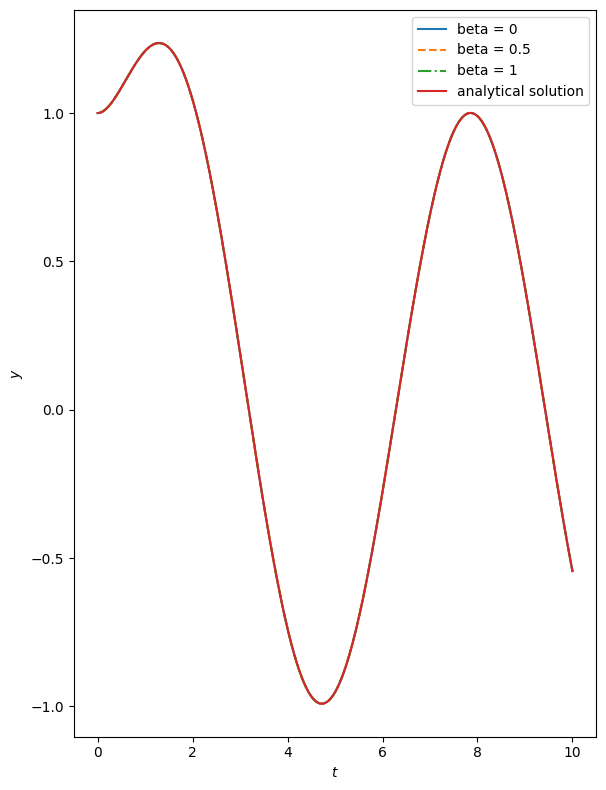

In [ ]:
# Test the linear solver

# set up the inputs for LinearBetaMethod to test it on the problem described at
# page 6 of the pdf, right before the discussion question for different values
# of beta. Use the following time range and initial condition

#Set up the inputs for LinearBetaMethod
tRange_linear = np.array([0,10])
Lambda_test = -1
beta_values = [0, 0.5, 1]
value_h = 0.0001
u0_test = np.array([1])

#Define the test function g
test_g_1 = lambda t: -1*Lambda_test*np.sin(t)+np.cos(t)

#Analytical solution to the IVP is defined below (look theory)
def analytical_solution(Lambda, t_array):
  analytical = np.zeros(len(t_array))
  for i in range(len(t_array)):
    t = t_array[i]
    analytical[i] = np.exp(Lambda*t) + np.sin(t)
  return analytical


# then create a single figure with 3 plots
# change the line style to make it more readable, as we expect the solutions
# to be very close to each other; here's a possible choice for different line
# styles you can use

#The tArray is the same for the three plots, so only the first is plotted to reduce computation time

fig, ax = plt.subplots(1,1, figsize = (8,8))
linestyle = ['-','--','-.']
for i in range(len(beta_values)):
  beta = beta_values[i]
  tArray_1, solArray_1 = LinearBetaMethod(Lambda = Lambda_test, g=test_g_1, tRange=tRange_linear, u0=u0_test, beta=beta, h=value_h)
  ax.plot(tArray_1, solArray_1[:,0], label = f'beta = {beta_values[i]}', linestyle= linestyle[i])

#Plot analytical solution too
ax.plot(tArray_1, analytical_solution(Lambda=-1, t_array=tArray_1), label= f"analytical solution")

ax.set_xlabel('$t$')
ax.set_ylabel('$y$')
ax.legend(loc='best', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()



We can clearly see that for $h=0.0001$ there is no visual difference between the results for β = {0, 0.5, 1} and h = 0.0001 with respect to the analytical solution.

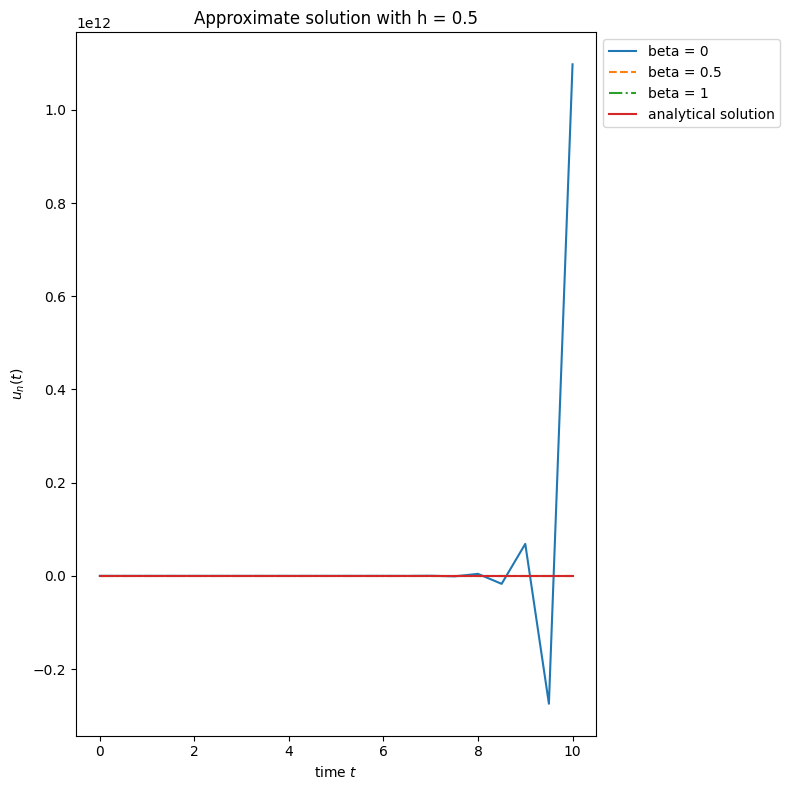

In [ ]:
## Discussion question A.1 (a)-(b)

#Change value of Lambda
Lambda_test_2 = -10
test_g_2 = lambda t: -1*Lambda_test_2*np.sin(t) + np.cos(t)

def analytical_solution_2(t):
  return np.exp(Lambda_test_2*t) + np.sin(t)

# set up the new inputs for LinearBetaMethod and the analytical solution
# for each value of h create a figure containing the analytical solution and the
# 3 numerical solutions

values_h = [0.5, 0.125]
fig, ax = plt.subplots(1,1, figsize = (8,8))
linestyle = ['-','--','-.']
for i in range(len(beta_values)):
  beta = beta_values[i]
  tArray_2, solArray_2 = LinearBetaMethod(Lambda=-10, g=test_g_2, tRange =tRange_linear, u0=u0_test, beta=beta, h=0.5)
  ax.plot(tArray_2, solArray_2[:,0], label = f'beta = {beta_values[i]}', linestyle= linestyle[i])
  #Plot analytical solution too
ax.plot(tArray_2, analytical_solution(Lambda=-10, t_array=tArray_2), label= f"analytical solution")
ax.set_xlabel(r'time $t$')
ax.set_ylabel(r'$u_n(t)$')
ax.set_title(f'Approximate solution with h = {0.5}')
ax.legend(loc='best', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()



# Discussion question A.1 (a)
A-stability can be divided into two categories: unconditional and conditional A-stability. Due to the relationship $u_{m+1}=(A_{\beta}(\lambda h))^mu_0$ it follows that $|u_n| ⟶ 0$ if $|A_{\beta}(\lambda h)|\lt 1$.

From this fact it follows that in the linear case the stability criterion of the $\beta$-method states is:

*   Unconditionally stable for $\beta\ge \frac{1}{2}$
*   Conditionally stable for $0\leq \beta \lt\frac{1}{2}$

In the case of $0\leq \beta<\frac{1}{2}$, we have stability if $h < \frac{Re(λ)}{(β-\frac{1}{2})|λ|^2}= h_{\text{critical}}$.

This can be clearly seen in the graph, for $\beta=\frac{1}{2}$ and $\beta=1$ the solution is unconditionally stable, so the solution will tend to zero for any value of $h$, and it does not diverge.

On the other hand for $\beta=0$ the stability is conditional, and since $h=0.5$ and $λ=-10\Rightarrow 0.5<\frac{-10}{(0-\frac{1}{2})|-10|^2} = \frac{-10}{-50}=\frac{1}{5}=0.2$ the condition stated above is not acomplished. This implies the solution is not A-stable as it can be seen on the graph (line $\beta=0$ diverges).


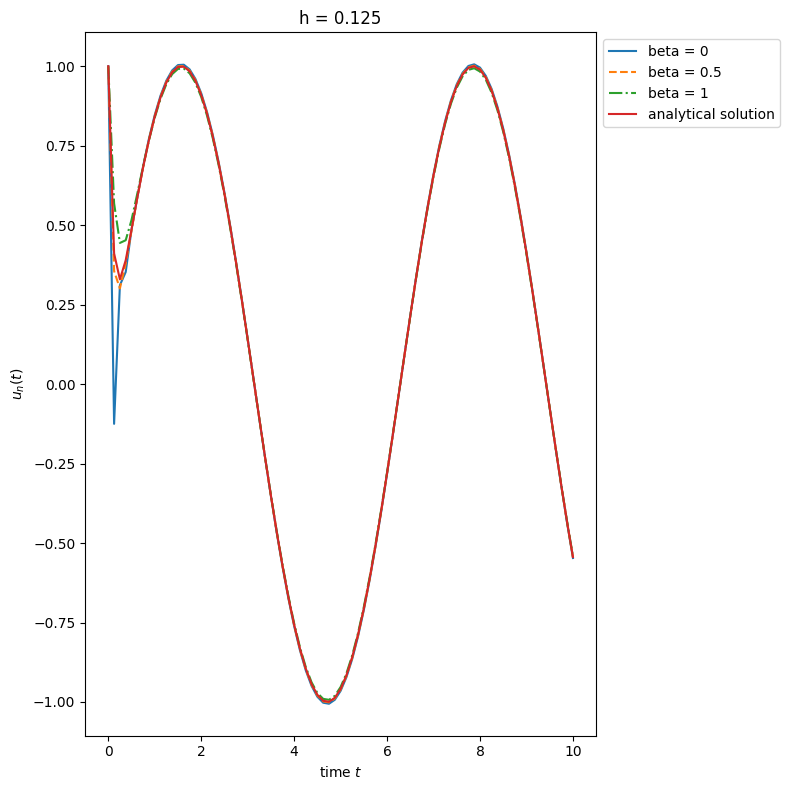

In [ ]:

fig, ax = plt.subplots(1,1, figsize = (8,8))
linestyle = ['-','--','-.']
for i in range(len(beta_values)):
  beta = beta_values[i]
  tArray_2, solArray_2 = LinearBetaMethod(Lambda=-10, g=test_g_2, tRange =tRange_linear, u0=u0_test, beta=beta, h=0.125)
  ax.plot(tArray_2, solArray_2, label = f'beta = {beta_values[i]}', linestyle= linestyle[i])
  #Plot analytical solution too
ax.plot(tArray_2, analytical_solution(Lambda=-10, t_array=tArray_2), label= f"analytical solution")
ax.set_xlabel(r'time $t$')
ax.set_ylabel(r'$u_n(t)$')
ax.set_title(f'h = {0.125}')
ax.legend(loc='best', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()


# Discussion question A.1 (b)

Following the reasoning in part (a) we have unconditional A-stability for $\beta =1$ and $\beta=\frac{1}{2}$ for any value of $h$.

On the other hand, for $\beta=0$ we have conditional stability. In this case since $h=0.125$  $λ=-10 \Rightarrow 0.125<\frac{-10}{(0-\frac{1}{2})|-10|^2} = \frac{-10}{-50}=\frac{1}{5}=0.2$ the condition is satisfied. Thus we have A-stability for this value of $h$ as can be observed on the graph above (solution does not diverge).

# **B. Accuracy of the $\beta$-method**

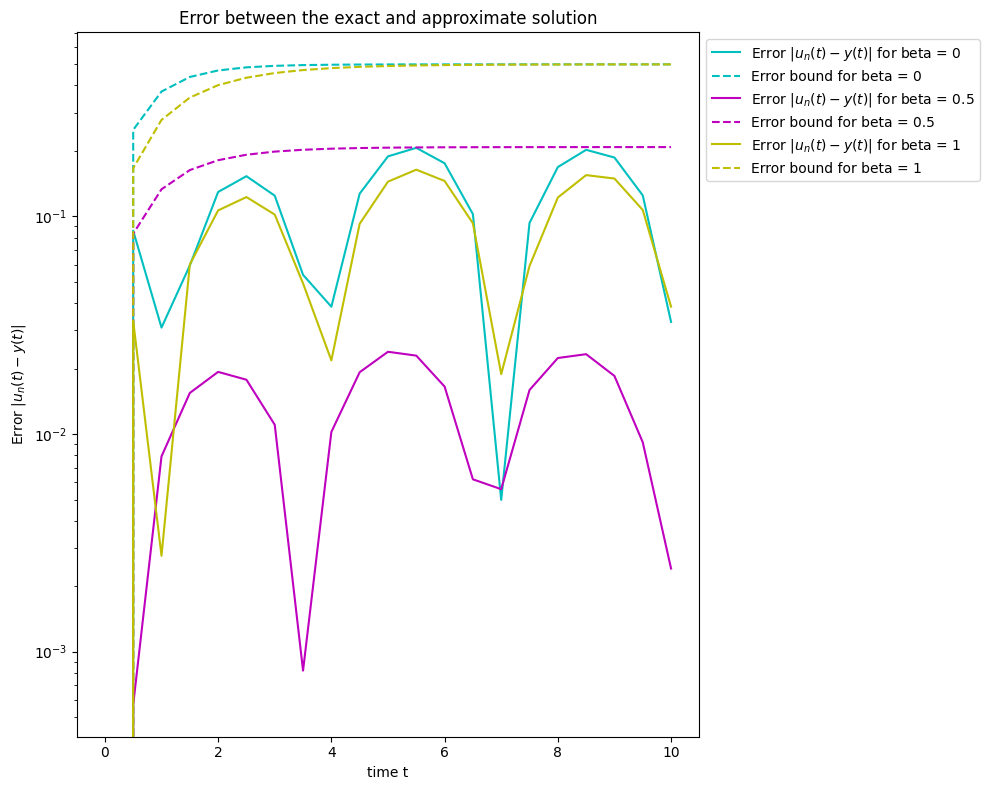

In [ ]:
## Discussion question B.1(a)
#Error plot between the exact solution together with the approximate solutions

#Set value of Lambda
Lambda_test = -1

#Define values of beta
beta_values = [0, 0.5, 1]

#Define the amplification factor A
def amplification_factor(h, Lambda, beta):
  A = ((1+(1-beta)*h*Lambda)/(1-beta*Lambda*h))
  return A

#Define function that computes tau_max
#This function has been changed to use the bounds provided in question 14,
#instead of the formal definition, so it only considers beta=0,0.5,1
def tau_max(Lambda, beta, h):
  if beta in (0, 1):
    tau = h**2*((1+np.abs(Lambda)**2)/2)
    return tau
  if beta == 0.5:
    tau = (h**3)*((1+np.abs(Lambda)**3)/24)+(0.375*h**3*np.abs(Lambda)*(1+np.abs(Lambda)**2))
    return tau


def error_bound_five(Lambda, tRange, beta, h):
  A = amplification_factor(h, Lambda, beta)
  numtime_steps = int((tRange[1]-tRange[0])/h)
  tau = tau_max(Lambda,beta, h)
  error_bounds = np.zeros(numtime_steps+1)
  for j in range(numtime_steps+1):
    error_bounds[j] = (tau*(1-np.abs(A)**j))/((1-np.abs(A))*np.abs(1-beta*h*Lambda))
  return error_bounds


#Plot
fig, ax = plt.subplots(1,1, figsize = (10,8))
colours = ['c', 'm', 'y']
for i in range(len(beta_values)):
  tArray_3, solArray_3 = LinearBetaMethod(Lambda=-1.0,g=test_g_1 , tRange= tRange_linear, u0=u0_test, beta=beta_values[i], h=0.5)
  an_solution = analytical_solution(-1.0, tArray_3)
  error = np.abs(an_solution - solArray_3[:,0])
  ax.semilogy(tArray_3, error, label = f'Error $|u_n(t)-y(t)|$ for beta = {beta_values[i]}', linestyle = '-', color = colours[i])
  error_bounds = error_bound_five(Lambda_test, tRange_linear, beta=beta_values[i], h=0.5)
  ax.semilogy(tArray_3, error_bounds, label = f'Error bound for beta = {beta_values[i]}', linestyle = '--', color = colours[i])

ax.set_title("Error between the exact and approximate solution")
ax.set_xlabel('time t')
ax.set_ylabel(r'Error $|u_n(t)-y(t)|$')
ax.legend(loc='best', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()



# Discussion question B.1 (a)
Clearly from the graph the error for $\beta=0.5$ is the lowest. This follows from the fact that, as derived in the lecture, the truncation error $\tau_m$ follows order $o(h^2)$ for $\beta=0,1$ and order $o(h^3)$ for $\beta=0.5$. Thus it follows that both the error bound and the true error for $\beta=0.5$ is lower than for the other two values of $\beta$.

The slope of the line for beta=0 is: 0.9290231740217129.
The slope of the line for beta=0.5 is: 1.9440842544877104.
The slope of the line for beta=1 is: 1.0135535114870498.


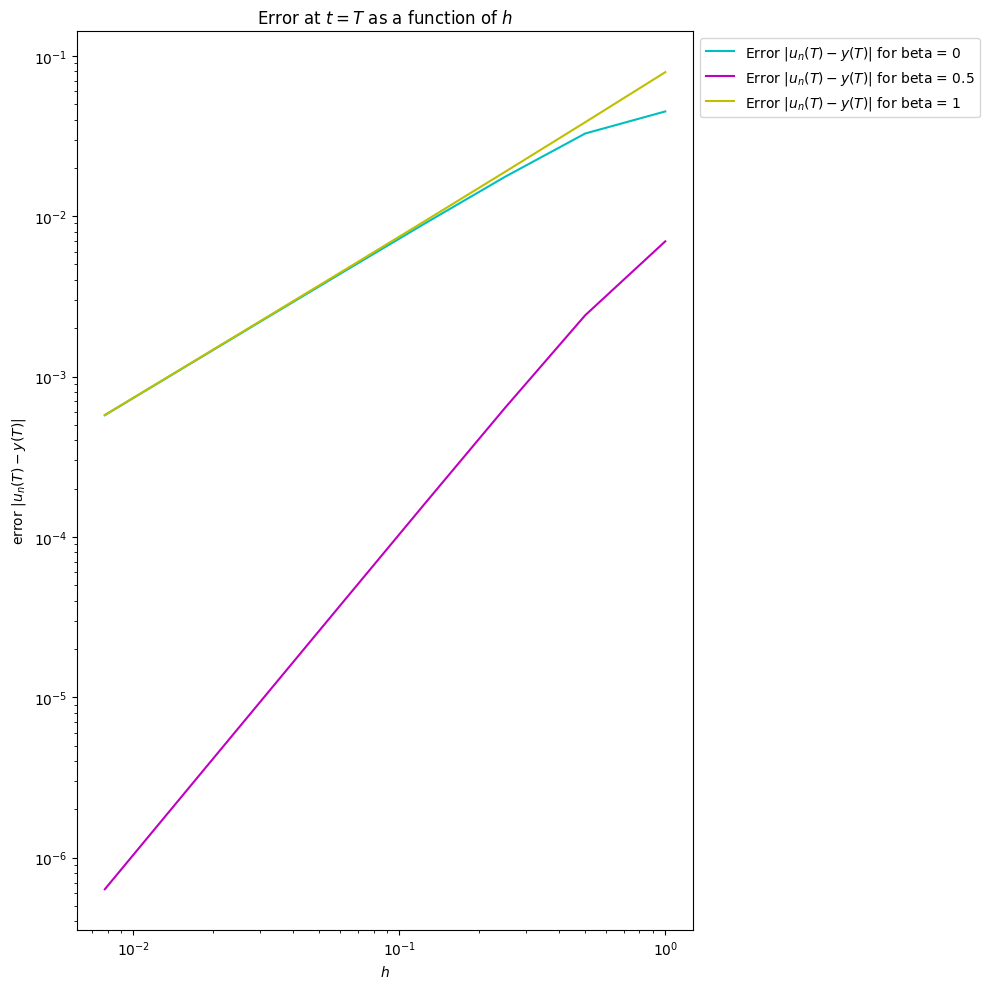

In [ ]:
## Discussion question B.1(b)


#Set up the correct values for h
h_values = np.zeros(8)
for j in range(8):
  h_values[j] = 2**(-j)

#Error at t = T for β = 0, 0.5, 1 as function of h
fig, ax = plt.subplots(1,1, figsize = (10,10))
colours = ['c', 'm', 'y']
for i in range(0, 3):
  beta = beta_values[i]
  error_timeT = np.zeros(8)
  h_values = np.zeros(8)
  for j in range(8):
    h_values[j] = 2**(-j)
    tArray_4, solArray_4 = LinearBetaMethod(Lambda_test, test_g_1, tRange_linear, u0=u0_test, beta=beta, h=2**(-j))
    #To compute the error at time T select the last entry of solArray
    #In this case the input u0 is a scalar so selecting solArray[-1] and doing .abs works.
    #To ensure this works for the multivariable case np.linalg.norm is applied
    error_timeT[j] = np.linalg.norm(analytical_solution(Lambda=-1, t_array=tArray_4)[-1] - solArray_4[-1][0])
  ax.loglog(h_values, error_timeT, label = f'Error $|u_n(T)-y(T)|$ for beta = {beta}', linestyle = '-', color = colours[i])
  #Compute the slopes of each of the lines
  slope, intercept = np.polyfit(np.log(h_values), np.log(error_timeT), 1)
  print(f"The slope of the line for beta={beta} is: {slope}.")

ax.set_title("Error at $t=T$ as a function of $h$")
ax.set_xlabel('$h$')
ax.set_ylabel(r'error $|u_n(T)-y(T)|$')
ax.legend(loc='best', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()

#Compute the slopes of each of the lines




# Discussion question B.1 (b)
The results above give an approximate slope of 1 for $\beta=0,1$ and a slope of 2 for $\beta=0.5$. This is consistent with the derivation in the tutorial.

As stated in part (a) the term $\tau_{max}(h)$ is of order $o(h^2)$ for $\beta=0,1$ and order $o(h^3)$ for $\beta=0.5$. Moreover, we found the following expression for the error bound:
\begin{equation}
|y_{n+1}-u_{n+1}|\le \frac{\tau_{max}(h)}{|1-\beta h \lambda|}\frac{1-|A_{\beta}(\lambda h)|^{n+1}}{1-|A_{\beta}(\lambda h)|}
\end{equation}
Since we are comparing $y_{n+1}$ and $u_{n+1}$ for a fixed $T$ we can apply the result that as $h  \rightarrow 0$ the amplification factor $1-|A_{\beta}(\lambda h)|^{T/h}$ tends to $1-e^{\lambda T}$, which does not depend on $h$. Thus the error as $h \rightarrow 0$ is bounded by:
\begin{equation}
\varepsilon(T)=|y_{n+1}(T)-u_{n+1}(T)|\le \frac{\tau(h)(1-e^{\lambda T})}{-\lambda h}
\end{equation}
This directly implies that the error is of order $o(h)$ for $\beta=0,1$ and order $o(h^2)$ for $\beta=0.5$ (i.e. a factor of $h$ cancels out). This is consistent with the slope of the graphs above.

Following this argument the value of $\beta=0.5$ makes the error decrease faster as $h \rightarrow 0$.

# Discussion question B.2

Now we discuss the differences between the three methods resulting from the three different values of $\beta$. Think of the following criteria: order of accuracy, absolute stability, explicit vs. implicit.



*   $\beta=0$:

The $\beta$-method is **explicit**: this is an **Euler forward method** so it only depends on the previous step in order to compute the next approximate value for the solution. A-stability is **conditional**: depends on the value of $h$ under which the $\beta$-method is being applied. The order of accuracy is **first-order** $o(h)$ (i.e. the error at a fixed time $t$ decreases linearly as $h$ tends to zero).

*   $\beta=0.5$:

The $\beta$-method is **implicit**: the next approximate value depends on both the previous step and the new value, thus the solution of an implicit equation is required at each step. A-stability is **unconditional**, the solution remains stable for any value of the step-size $h$. The order of accuracy is **second-order** $o(h^2)$ (i.e. the error at a fixed time $t$ decreases quadratically as $h$ tends to zero).

*   $\beta=1$:

The $\beta$-method is **implicit**: the next approximate value depends on both the previous step and the new value, thus the solution of an implicit equation is required at each step. A-stability is **unconditional**, the solution remains stable for any value of the step-size $h$. The order of accuracy is **first-order** $o(h)$ (i.e. the error at a fixed time $t$ decreases linearly as $h$ tends to zero).





## **C. The $\beta$-method for a system of IVP**

Newton's method for systems of equations can be written as a fixed-point iteration where the iteration function is given by:
\begin{equation}
\textbf{G}_N(\textbf{x})=\textbf{x}-\textbf{J}_{\textbf{F}}(\textbf{x})^{-1}\textbf{F}(\textbf{x})
\end{equation}
fpIterator_2 is the modified implementation of fpIterator so that it also works for systems of nonlinear equations, so we now define an alternative Newton Method function applying the definition above.

The Newton method is applied to solve the implicit equation that appears in the $\beta$-method in the implicit case.
The system to solve is now given by $\mathbf{F}(\mathbf{u}_{n+1}) = 0, \quad
\mathbf{F}(\mathbf{x}) = \mathbf{x} - \mathbf{u}_n - h f \big( t_{n+\beta}, (1-\beta) \mathbf{u}_n + \beta \mathbf{x} \big)$ where the Jacobian of $\mathbf{F}$ is given by $\mathbf{J}_{\mathbf{F}}(\mathbf{x}) = \mathbf{I} - h \beta \mathbf{J}_f \big( (1-\beta) \mathbf{u}_n + \beta \mathbf{x} \big)$.

Thus in the linear case (for $f$) the Jacobian simplifies to the identity matrix. Hence the newton method that appears in the implicit case for the $\beta$-method has to converge in one step (since it is a constant matrix).

In [ ]:
##Version of newton() from Unit 2

#Version of newton() that allows for multivariable systems
#fpIterator function that finds the fixed point of a certain function phi
def fpIterator(phi, x0, tol, maxit):

    errEst = [np.linalg.norm(phi(x0)-x0)]
    xHist = [x0]
    x = x0
    success = False  # Initialize success to False

    for i in range(maxit):
      if errEst[-1] < tol:
        success = True
        break
      else:
        x_k = phi(xHist[-1])
        errEst.append(np.linalg.norm(x_k-xHist[-1]))
        xHist.append(x_k)
    x = xHist[-1]
    return x, success, errEst, xHist

#Definition of Newton's method for a system of equations (formula above)
def newton(F, J_inverse, x0, tol, maxit):
  G_N = lambda y: (y - np.matmul(J_inverse(y), F(y)))
  x, success, errEst, xHist = fpIterator(G_N, x0, tol, maxit)

  return x, success, errEst, xHist


In [ ]:
# Performs integration for the system of IVPs given by
#           d/dt u = f(t, u), u(t_0) = u_0
# using the beta-method
# INPUT
# f             the right-hand side function, the output should be a
#               N x 1 array where N is the number of unknowns
# tRange        the time interval [t_0, T] of integration
# u0            initial solution at t = tRange(1) (N x 1 array)
# df            a function that evaluates the Jacobian matrix of f
# beta          defines the method
# h             the step-size
#
# OUTPUT
# tArray        array containing the time points
# solArray      array containing the solution at each time point
#               (the ith row equals the solution at time tArray(i))

#Set the maximum number of iterations and error tolerance
max_iterations = 50
error_tol = 1e-12


def BetaMethod(f, tRange, u0, df, beta, h):

    # initialize your output as for the linear version and set up th newton()
    # inputs

    numtime_steps = int((tRange[1]-tRange[0])/h)
    #Create array of values of t
    tArray = np.zeros(numtime_steps+1)
    for i in range(numtime_steps+1):
      tArray[i] = tRange[0] + i*h

    #Adjust the shape of solArray depending on the shape of u0
    if u0.shape[0] > 1:
      dimension_m = u0.shape[0]
      solArray = np.zeros((numtime_steps+1, dimension_m, 1))
    else:
      dimension_m = u0.shape[0]
      solArray = np.zeros((numtime_steps+1, u0.shape[0]))

    #Set first value of solArray to be the initial condition
    #Printear dimension para checkear
    solArray[0, :] = u0
    #initialize the loop
    for i in range(1, len(tArray)):
      time_step = tArray[i-1]
    #Explicit Euler method for beta=0
      if beta == 0:
        u_next = solArray[i-1] + h*f(time_step, solArray[i-1])
        solArray[i] = u_next

    #For beta non-zero the Euler method is implicit
      else:
        #Now F is defined as F(x)=x-u_n-h*f(tn+beta, (1-beta)*u_n+beta*u_n+1)
        un = solArray[i-1]
        F = lambda x: (x-un-h*f((time_step+beta*h), (1-beta)*un+beta*x))
        #Define the Jacobian matrix of the map F in terms of the jacobian of the (non)linear function f
        DF = lambda z: np.identity(dimension_m) - (h*beta*df(((1-beta)*un + beta*z)))
        #Compute the inverse of the Jacobian matrix, two cases depending on whether DF is a scalar of a matrix
        if dimension_m == 1:
          DF_inverse = lambda t: 1/DF(0)
        else:
          DF_inverse = lambda x: np.linalg.inv(DF(x))
        #Define the initial condition X_0 to the newton method
        #From the lecture notes this is u^(0)_m+1 = u_m
        X0 = un
        u_next, success, errEst, xHist = newton(F, DF_inverse, X0, tol=error_tol, maxit=max_iterations)

        solArray[i,:] = u_next
        #Raise error and break the loop if newton() does not converge
        if success == True:
          print(f"Newton method has converged after {len(errEst)-2} iterations for t={time_step}.")
          continue
        else:
          warnings.warn(f"Newton method has failed after {len(errEst)-2} iterations (tolerance was {error_tol}) for t={time_step}.")
          print(f"Newton method has failed after {len(errEst)-2} iterations (tolerance was {error_tol}) for t={time_step}.")
          break

    return tArray, solArray

............................
Newton method has converged after 1 iterations for t=0.0.
Newton method has converged after 1 iterations for t=0.025.
Newton method has converged after 1 iterations for t=0.05.
Newton method has converged after 1 iterations for t=0.07500000000000001.
Newton method has converged after 1 iterations for t=0.1.
Newton method has converged after 1 iterations for t=0.125.
Newton method has converged after 1 iterations for t=0.15000000000000002.
Newton method has converged after 1 iterations for t=0.17500000000000002.
Newton method has converged after 1 iterations for t=0.2.
Newton method has converged after 1 iterations for t=0.225.
Newton method has converged after 1 iterations for t=0.25.
Newton method has converged after 1 iterations for t=0.275.
Newton method has converged after 1 iterations for t=0.30000000000000004.
Newton method has converged after 1 iterations for t=0.325.
Newton method has converged after 1 iterations for t=0.35000000000000003.
Newton me

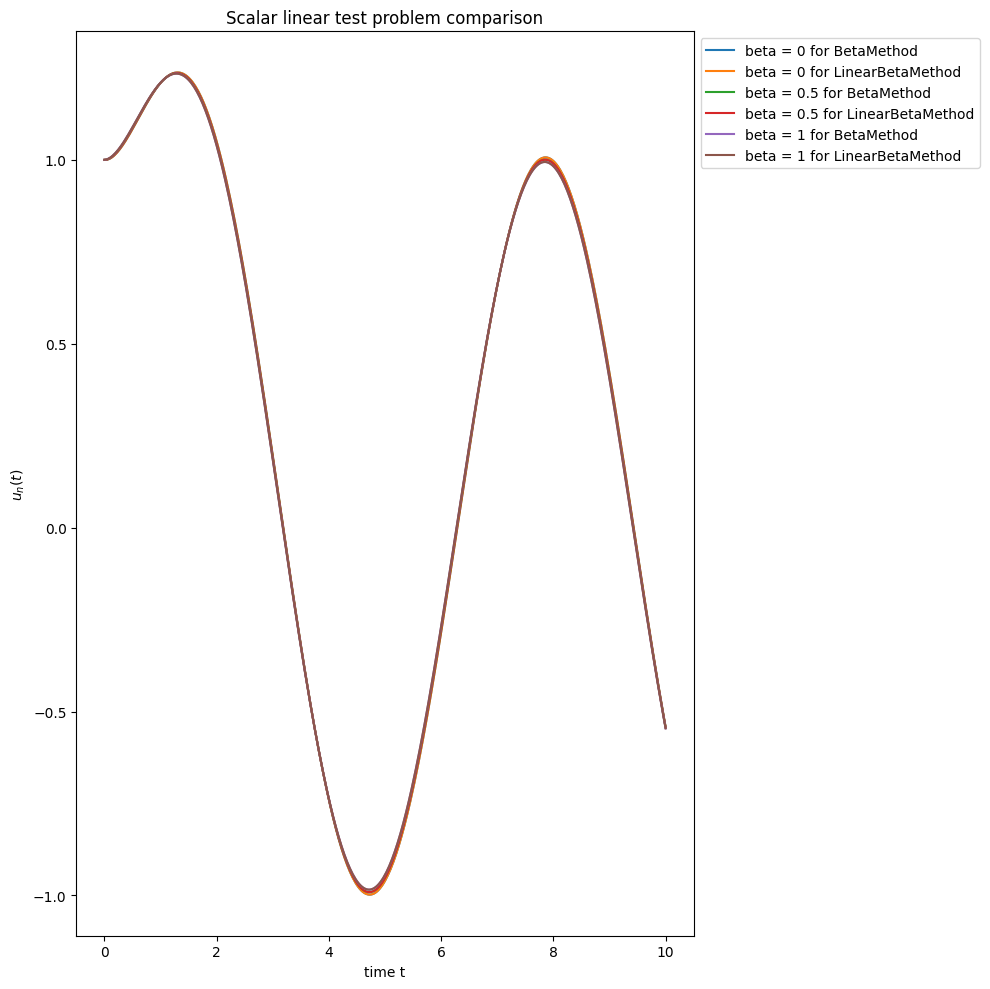

In [ ]:
#Linear test problem (6) to verify that the solution has not changed compared
#to the one obtained from linearBetaMethod for a few values beta

#Values of beta and setting h = 0.025
beta_values = [0, 0.5, 1]
trial_h = 0.025
#Set the range of t as earlier
tRange_linear = np.array([0,10])

#Defintion of function f(t,y)
Lambda = -1.0
linear_test_f = lambda t, y: Lambda*(y-np.sin(t)) + np.cos(t)
#The jacobian for this linear test is simply Lambda
Jacobianf_linear_test = lambda t: Lambda
#The initial condition is set to 1 as earlier
u0_test = np.array([1])

#It is IMPORTANT to check that Newton iterations converge in one step since the problem is linear

#To verify that they are the same plot a graph
fig, ax = plt.subplots(1,1, figsize = (10,10))
for i in range(len(beta_values)):
  beta = beta_values[i]
  tArray_1, solArray_1 = BetaMethod(linear_test_f, tRange_linear, u0=u0_test, df=Jacobianf_linear_test, beta=beta, h=trial_h)
  tArray_2, solArray_2 = LinearBetaMethod(Lambda_test, test_g_1, tRange_linear, u0=u0_test, beta=beta, h=trial_h)
  ax.plot(tArray_1, solArray_1, label = f'beta = {beta_values[i]} for BetaMethod')
  ax.plot(tArray_2, solArray_2, label = f'beta = {beta_values[i]} for LinearBetaMethod')
  print("............................")

ax.set_title("Scalar linear test problem comparison")
ax.set_xlabel('time t')
ax.set_ylabel(r'$u_n(t)$')
ax.legend(loc='best', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()


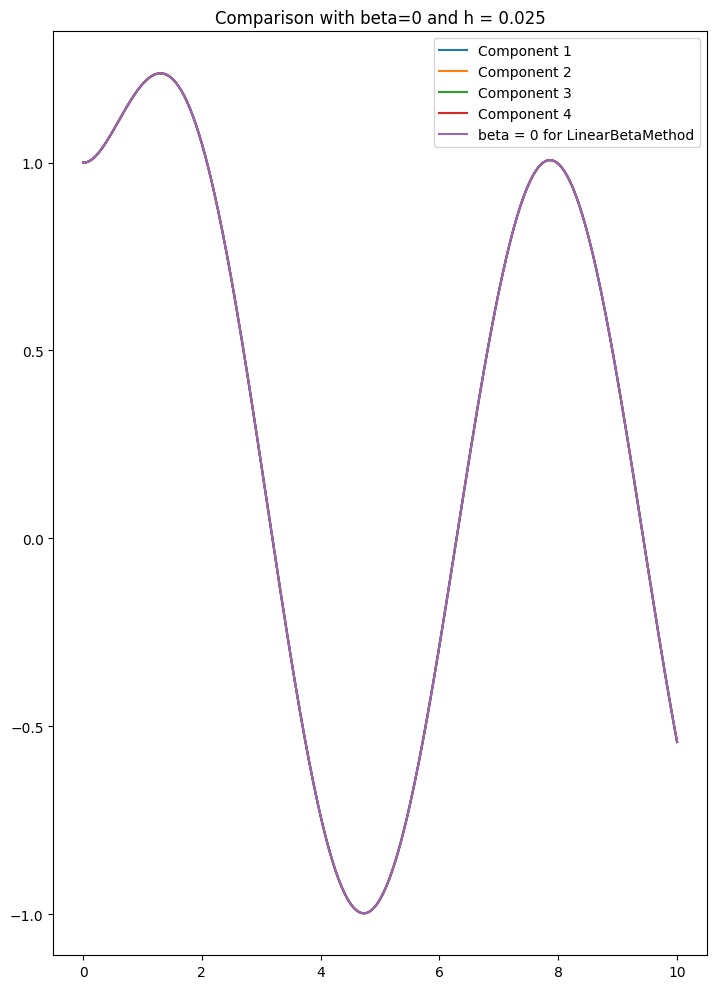

Newton method has converged after 1 iterations for t=0.0.
Newton method has converged after 1 iterations for t=0.025.
Newton method has converged after 1 iterations for t=0.05.
Newton method has converged after 1 iterations for t=0.07500000000000001.
Newton method has converged after 1 iterations for t=0.1.
Newton method has converged after 1 iterations for t=0.125.
Newton method has converged after 1 iterations for t=0.15000000000000002.
Newton method has converged after 1 iterations for t=0.17500000000000002.
Newton method has converged after 1 iterations for t=0.2.
Newton method has converged after 1 iterations for t=0.225.
Newton method has converged after 1 iterations for t=0.25.
Newton method has converged after 1 iterations for t=0.275.
Newton method has converged after 1 iterations for t=0.30000000000000004.
Newton method has converged after 1 iterations for t=0.325.
Newton method has converged after 1 iterations for t=0.35000000000000003.
Newton method has converged after 1 it

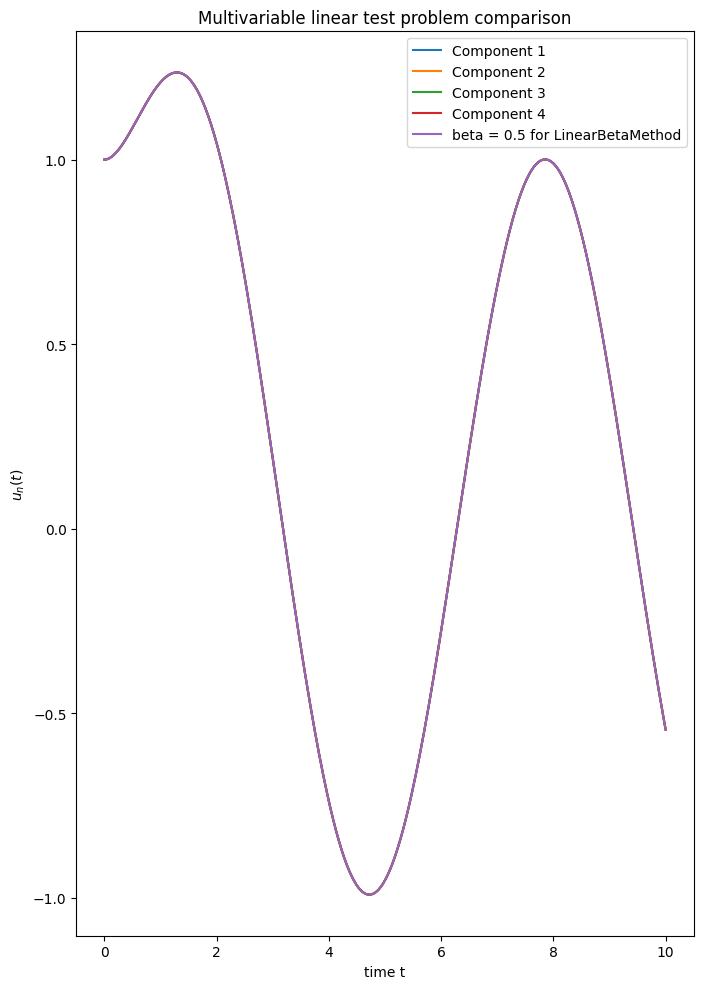

In [ ]:
##Now the function is applied to a system of ODEs where
#each ODE corresponds to the problem (6). Each component
#of the solution vector is equal to the solution of the scalar problem.

#Assume system of ODEs of size 4
multivariable_testf = lambda t, y: np.array([Lambda*(y[0]-np.sin(t)) + np.cos(t), Lambda*(y[1]-np.sin(t)) + np.cos(t),
                                            Lambda*(y[2]-np.sin(t)) + np.cos(t), Lambda*(y[3]-np.sin(t)) + np.cos(t)])
#The Jacobian of this map is easily computed to be Lambda*Indentity(4)
Jacobianf_multivariable = lambda t: Lambda*np.identity(4)

#Set initial condition to be entry full of 1s
u0_multivariable = np.array([[1],[1],[1],[1]])


#Verify Beta function works appropiately
#To verify that that each component is indeed a solution to the linear single
#variable problem we will plot each component and should give the same result
#print(BetaMethod(multivariable_testf, tRange, u0_multivariable, Jacobianf_multivariable, 0, 0.025))

fig, ax = plt.subplots(1,1, figsize = (10,10))
for i in range(4):
  tArray, solArray = BetaMethod(multivariable_testf, tRange_linear, u0_multivariable, Jacobianf_multivariable, 0, 0.025)
  #Make sure the correct component is selected
  ax.plot(tArray, solArray[:,i], label = f'Component {i+1}')
tArray_2, solArray_2 = LinearBetaMethod(Lambda_test, test_g_1, tRange_linear, u0=u0_test, beta=0, h=0.025)
ax.plot(tArray_2, solArray_2, label = f'beta = {0} for LinearBetaMethod')
ax.set_title(f"Comparison with beta=0 and h = 0.025")
ax.legend(loc='best', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()


fig, ax = plt.subplots(1,1, figsize = (10,10))
for i in range(4):
  tArray, solArray = BetaMethod(multivariable_testf, tRange_linear, u0_multivariable, Jacobianf_multivariable, 0.5, 0.025)
  #Make sure the correct component is selected
  ax.plot(tArray, solArray[:,i], label = f'Component {i+1}')

tArray_2, solArray_2 = LinearBetaMethod(Lambda_test, test_g_1, tRange_linear, u0=u0_test, beta=0.5, h=0.025)
ax.plot(tArray_2, solArray_2, label = f'beta = {0.5} for LinearBetaMethod')
ax.set_title(f"Comparison with beta=0.5 and h = 0.025")
ax.legend(loc='best', bbox_to_anchor=(1, 1))


ax.set_title("Multivariable linear test problem comparison")
ax.set_xlabel('time t')
ax.set_ylabel(r'$u_n(t)$')
fig.tight_layout()
plt.show()



In both cases the solution is reached in a single iteration, which is what we would expect for this system. Moreover all the components of the solution vector indeed match with each other and with the analytical solution. This is a sanity check for the correct implementation of the $\beta$-method.

# Application 1: Two-body dynamics
$\textbf{g}(\textbf{x}, M)=-\frac{GM\textbf{x}}{\parallel \textbf{x}\parallel^3_2}$ and the corresponding Jacobian $\textbf{J}_{\textbf{g}}(\textbf{x}, M)=\frac{GM\textbf{x}}{\parallel \textbf{x}\parallel^3_2}(-\textbf{I}_3+\frac{3\textbf{xx}^T}{\parallel \textbf{x}\parallel^2_2})$

In [ ]:
# INPUT
# x             position of dynamic body
# G             gravitational constant
# M             mass of attracting body
#
# OUTPUT
# g             gravitational acceleration

def gravAccF(x, G, M):
  #Formula in equation (9)
  g = -G*M*(x/np.linalg.norm(x)**3)
  return g

In [ ]:
# INPUT
# x             position of dynamic body
# G             gravitational constant
# M             mass of attracting body
#
# OUTPUT
# jacG          Jacobian of gravitational acceleration w.r.t. position x

def gravAccJac(x, G, M):
   # use the formula in equation (11)
   x = np.array(x)
   jacG = (G*M*x/(np.linalg.norm(x)**3))*(-1*np.identity(3) + (3*np.matmul(x, np.transpose(x)))/(np.linalg.norm(x)**2))
   return jacG.reshape((3,3))


In [ ]:
#Function f for the two body dynamics and corresponding Jacobian using the
#gravAccf and gravAccJac defined above

#Define the values of the constants G, R and M
R =1
M =1
G = 4*np.pi**2

def dynamic_f(t, y):
  return np.concatenate((gravAccF(y[3:6], G, M), y[0:3])).reshape(6, 1)

def dynamicJac_f(y):
  return np.block([[np.zeros((3,3)), gravAccJac(y[3:6], G, M)],[np.identity(3), np.zeros((3,3))]])



#Circular orbit for one period
#First define the angular velocity
angular_velocity = np.sqrt((G*M)/(R**3))

#The exact solution is set to be the initial condition
position_orbit_exact = lambda t: np.array([R*np.cos(angular_velocity*t), R*np.sin(angular_velocity*t), 0]).reshape(3, 1)

#The deivative of the position vector is defined as the initial condition for the velocity component
velocity_orbit_exact = lambda t: np.array([-angular_velocity*R*np.sin(angular_velocity*t), angular_velocity*R*np.cos(angular_velocity*t), 0]).reshape(3, 1)

#Initial condition is [x_0, v_0]
initial_condition = np.concatenate([velocity_orbit_exact(0), position_orbit_exact(0)]).reshape(6, 1)
#Define the time step to be h=2^(-6)T
period_T = 2*np.pi/angular_velocity
time_step_h = 2**(-6)*period_T


Newton method has converged after 5 iterations for t=0.0.
Newton method has converged after 5 iterations for t=0.015625.
Newton method has converged after 5 iterations for t=0.03125.
Newton method has converged after 5 iterations for t=0.046875.
Newton method has converged after 5 iterations for t=0.0625.
Newton method has converged after 5 iterations for t=0.078125.
Newton method has converged after 5 iterations for t=0.09375.
Newton method has converged after 5 iterations for t=0.109375.
Newton method has converged after 5 iterations for t=0.125.
Newton method has converged after 5 iterations for t=0.140625.
Newton method has converged after 5 iterations for t=0.15625.
Newton method has converged after 5 iterations for t=0.171875.
Newton method has converged after 5 iterations for t=0.1875.
Newton method has converged after 5 iterations for t=0.203125.
Newton method has converged after 5 iterations for t=0.21875.
Newton method has converged after 5 iterations for t=0.234375.
Newton m

<ipython-input-9-ab9f0ac6de24>:76: UserWarning: Newton method has failed after 49 iterations (tolerance was 1e-12) for t=0.359375.
  warnings.warn(f"Newton method has failed after {len(errEst)-2} iterations (tolerance was {error_tol}) for t={time_step}.")


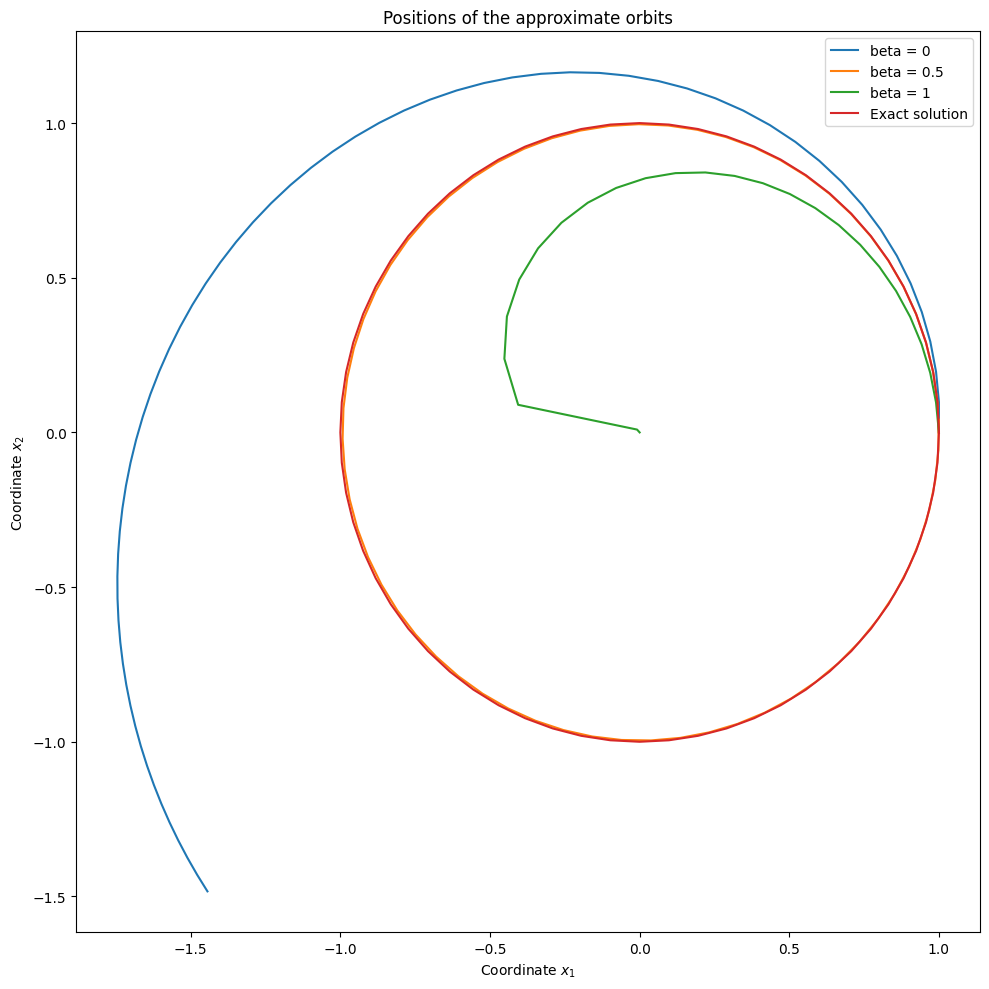

In [ ]:
## Discussion question C.1

# then define all the inputs for BetaMethod() and the exact solution function
# handle; use the following syntax to define function handles
#       f = lambda var1, var2, var3: ...
# the code will be considerably more readable

# other parameter needed: beta, h, time range

# finally solve the system using BetaMethod() and plot (x_1(t), x_2(t)) for
# the 3 values of beta in the samee figure together with the exact solution
#Define values of beta and the time_range
beta_values = [0, 0.5, 1]
time_range = [0, period_T]
fig, ax = plt.subplots(1,1, figsize = (10,10))
for i in range(len(beta_values)):
  beta = beta_values[i]
  tArray, solArray = BetaMethod(dynamic_f, time_range, u0=initial_condition, df=dynamicJac_f, beta=beta, h=time_step_h)
  #Return the position (x_1(t), x_2(t))
  x_1 = solArray[:,3,:]
  x_2 = solArray[:,4,:]
  ax.plot(x_1, x_2, label = f'beta = {beta}')

#Plot the exact solution for (x_1(t), x_2(t))
exact_position_1 = np.array([position_orbit_exact(t)[0, 0] for t in tArray])
exact_position_2 = np.array([position_orbit_exact(t)[1, 0] for t in tArray])
ax.plot(exact_position_1, exact_position_2, label = 'Exact solution')

ax.set_title("Positions of the approximate orbits")
ax.set_xlabel('Coordinate $x_1$')
ax.set_ylabel('Coordinate $x_2$')
ax.legend()
fig.tight_layout()
plt.show()

# Discussion question C.1
During the tutorial we found that:
\begin{equation}
\frac{\mathbf{L}(\mathbf{v}_{n+1}, \mathbf{x}_{n+1}) - \mathbf{L}(\mathbf{v}_n, \mathbf{x}_n)}{h}
= h (1 - 2\beta) \frac{GM}{\|\mathbf{x}_{n+\beta}\|_2^3} \mathbf{L}(\mathbf{v}_{n+\beta}, \mathbf{x}_{n+\beta})
\end{equation}
From the ODEs describing the system itself it follows that $\frac{d}{dt} L = 0$ so for any correct description of the system it must follow that the angular momentum is conserved.


For $\beta=0.5$ the numerical solution matches the analytical solution. This is due to the fact that by the formula above the angular momentum $\mathbf{L}$ is exactly conserved.

On the other hand for $\beta=0$ it can be shown that the angulat momentum $|\| L(\mathbf{v}_n, \mathbf{x}_n) \|\|_2
$ is monotically increasing. Thus the system is not well approximated by this method, and this explains why the orbit increases in radius with increasing time $t$ (i.e. as the angular momentum increases due to the $\beta$-method, the radius of the orbit has to increase too) and hence diverges as it can be seen above.

For the case $\beta=1$ the angular momentum $|\| L(\mathbf{v}_n, \mathbf{x}_n)\|\|_2$ decreases monotically which implies that the system is not well approximated, and this leads to the orbit's radius to decrease. Moreover, Newton method stops to converge appropiately after some time under this error tolerance and number of iterations. This can be due to the fact that there is no longer a solution to which the function $G_n(x)$



In [ ]:
#We plot the 2-norm of the error: for β = 0, 0.5, 1
#compute the approximate orbit for h = 2−lT, where l = 4 . . . , 12.
beta_values = [0, 0.5, 1]
l_values = np.arange(4,13)
values_h = (2.0)**-l_values

#Define the exact solution with time t:
exact_solution_vector = lambda t: np.concatenate([velocity_orbit_exact(t), position_orbit_exact(t)]).reshape(6, 1)

fig, ax = plt.subplots(1,1, figsize = (10,10))
for i in range(len(beta_values)):
  beta = beta_values[i]
  errors = np.zeros(len(values_h))
  for j in range(len(values_h)):
    h = values_h[j]
    tArray, solArray = BetaMethod(dynamic_f, time_range, u0=initial_condition, df=dynamicJac_f, beta=beta, h=h)
    T = tArray[-1]
    exact_solution_T = exact_solution_vector(T)
    np.linalg.norm(solArray[-1]-exact_solution_T)
    errors[j] = np.linalg.norm(solArray[-1] - exact_solution_T)
  ax.loglog(values_h, errors, label = f'beta = {beta}')

#Including functions y=h**2 and y=h
ax.loglog(values_h, values_h**2, label = '$h^2$')
ax.loglog(values_h, values_h, label = '$h$')

ax.set_title("Loglog plot of the error at time T for different values of h")
ax.set_xlabel('$h$ values')
ax.set_ylabel(r'error $|u_n(T)-y(T)|$')
ax.legend(loc='best',bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()


Se han truncado las últimas 5000 líneas del flujo de salida.
Newton method has converged after 3 iterations for t=0.62841796875.
Newton method has converged after 3 iterations for t=0.62890625.
Newton method has converged after 3 iterations for t=0.62939453125.
Newton method has converged after 3 iterations for t=0.6298828125.
Newton method has converged after 3 iterations for t=0.63037109375.
Newton method has converged after 3 iterations for t=0.630859375.
Newton method has converged after 3 iterations for t=0.63134765625.
Newton method has converged after 3 iterations for t=0.6318359375.
Newton method has converged after 3 iterations for t=0.63232421875.
Newton method has converged after 3 iterations for t=0.6328125.
Newton method has converged after 3 iterations for t=0.63330078125.
Newton method has converged after 3 iterations for t=0.6337890625.
Newton method has converged after 3 iterations for t=0.63427734375.
Newton method has converged after 3 iterations for t=0.634765625.
N

<ipython-input-9-ab9f0ac6de24>:76: UserWarning: Newton method has failed after 49 iterations (tolerance was 1e-12) for t=0.0625.
  warnings.warn(f"Newton method has failed after {len(errEst)-2} iterations (tolerance was {error_tol}) for t={time_step}.")
<ipython-input-9-ab9f0ac6de24>:76: UserWarning: Newton method has failed after 49 iterations (tolerance was 1e-12) for t=0.21875.
  warnings.warn(f"Newton method has failed after {len(errEst)-2} iterations (tolerance was {error_tol}) for t={time_step}.")
<ipython-input-9-ab9f0ac6de24>:76: UserWarning: Newton method has failed after 49 iterations (tolerance was 1e-12) for t=0.359375.
  warnings.warn(f"Newton method has failed after {len(errEst)-2} iterations (tolerance was {error_tol}) for t={time_step}.")
<ipython-input-9-ab9f0ac6de24>:76: UserWarning: Newton method has failed after 49 iterations (tolerance was 1e-12) for t=0.6015625.
  warnings.warn(f"Newton method has failed after {len(errEst)-2} iterations (tolerance was {error_tol})

Se han truncado las últimas 5000 líneas del flujo de salida.
Newton method has converged after 3 iterations for t=0.3759765625.
Newton method has converged after 3 iterations for t=0.376953125.
Newton method has converged after 3 iterations for t=0.3779296875.
Newton method has converged after 4 iterations for t=0.37890625.
Newton method has converged after 4 iterations for t=0.3798828125.
Newton method has converged after 4 iterations for t=0.380859375.
Newton method has converged after 4 iterations for t=0.3818359375.
Newton method has converged after 4 iterations for t=0.3828125.
Newton method has converged after 4 iterations for t=0.3837890625.
Newton method has converged after 4 iterations for t=0.384765625.
Newton method has converged after 4 iterations for t=0.3857421875.
Newton method has converged after 4 iterations for t=0.38671875.
Newton method has converged after 4 iterations for t=0.3876953125.
Newton method has converged after 4 iterations for t=0.388671875.
Newton metho

# Discussion question C.2
From these graphs we can see that the slope of the line $y=h^2$ is equal to that of the 2-norm error for $\beta=0.5$ (since in a loglog plot this is equal to slope 2). This implies that the order of accuracy is of order $o(h^2)$.

On the other hand, the slope of the line $y=h$ is approximately equal to the 2-norm error for $\beta=0$ and $\beta=1$. Thus the order of accuracy in both cases is of order $o(h)$.

The reason behind this is that the function used in this analysis $\mathbf{f}(t,\mathbf{y})$ is $[\textbf{g}(\textbf{x}, M), \mathbf{v}]^T$, thus each component $y_i$ is of the form $\lambda y_i +g(t)$ so we can apply some results discussed in the tutorial. We have that each component satisfies:

\begin{equation}
|y_{i, n+1}-u_{i, n+1}|\le \frac{\tau_{max}(h)}{|1-\beta h \lambda|}\frac{1-|A_{\beta}(\lambda h)|^{n+1}}{1-|A_{\beta}(\lambda h)|}
\end{equation}
and that the term $\tau_{max}(h)$ is of order $o(h^2)$ for $\beta=0,1$ and order $o(h^3)$ for $\beta=0.5$.

Since we are comparing $y_{i, n+1}$ and $u_{i, n+1}$ for a fixed $T$ and for each $i=1,...,6$ we can apply the result that as $h  \rightarrow 0$ the amplification factor $1-|A_{\beta}(\lambda h)|^{T/h}$ tends to $1-e^{\lambda T}$, which does not depend on $h$. Thus the error as $h \rightarrow 0$ is bounded by:
\begin{equation}
\varepsilon(T)=6·\text{max}_i|y_{i, n+1}(T)-u_{i, n+1}(T)|\le \frac{6\tau(h)(1-e^{\lambda T})}{-\lambda h}
\end{equation}
This directly implies that the error of each component and thus of the approximation method is of order $o(h)$ for $\beta=0,1$ and order $o(h^2)$ for $\beta=0.5$ (i.e. a factor of $h$ cancels out). This is consistent with the slope of the graphs above.

#Discussion question C.3

Consider the systems of non-linear ODEs given by:
\begin{equation}
    x'(t)=-3x^3(t)+y(t), \ y'(t)=-x(t)-y(t)
\end{equation}
with some non-zero initial conditions. Assume $x(t)$ and $y(t)$ and $t$ dimensionless.

#(a)
Show that:
\begin{equation}
    x^2(t) + y^2(t) \rightarrow 0
\end{equation}
as $t→∞$.

**Answer**:\
We will apply the Lyapunov direct method. \

We will define the scalar function $V:\mathbb{R}^2\to \mathbb{R}$ by $V(t)= x^2(t) + y^2(t)$ and prove it is a Liapunov function.


$\cdot$ For the first condition, we know that if $V(t)=0 \Rightarrow y^2(t)=-x^2(t)$. Since both sides have squared components and the left side of the equation is positive and the right one is negative, this implies that $V(t)=0 \iff x(t)=y(t)=0$.

$\cdot$ For the second condition, we have that $V(t)>0$ since $(x^2(t) + y^2(t))>0$.

$\cdot$ For the third condition, we compute the derivative:
\begin{equation}
    \frac{dV(t)}{dt}=2x'(t)x(t) + 2y'(t)y(t)= 2(-3x^3(t)+y(t))x(t) + 2(-x(t)-y(t))y(t)=−6x^4(t)−2y^2(t)=-2(3x^4(t)+y^2(t))\leq 0
\end{equation} \

Thus we have that $\frac{dV(t)}{dt} \leq 0$ for every $(x(t), y(t))$.


By Liapunov's method for stability we have that $x(t)\rightarrow 0$ and $y(t)\rightarrow 0$ when $t→∞$ which implies that $x^2(t) + y^2(t) \rightarrow 0$ as $t→∞$ as required.

#(b)
Discretize the problem using the Backward Euler method. Show that:
\begin{equation}
    x_n^2+y_n^2 → 0
\end{equation}
when $t_n → ∞$, for a fixed $h$, with $x_n ≈ x(t_n)$, $y_n ≈ y(t_n)$, and $t_n − t_{n−1} = h$.

**Answer**:\
By the Backward Eurler method ($\beta=0$), we have that:
\begin{equation}
    \dot x(t_{n+1}) ≈ \frac{x_{n+1}-x_n}{h} \\
    \dot y(t_{n+1}) ≈ \frac{y_{n+1}-y_n}{h}
\end{equation}
Plugging these expression on the respective derivatives gives:
\begin{equation}
    x_{n+1}=x_n-3hx_{n+1}^3+hy_{n+1}, \\
    y_{n+1}=y_n-hx_{n+1}-hy_{n+1}
\end{equation}
Mulitplying the first equation by $x_{n+1}$ and the second by $y_{n+1}$ we have that:
\begin{equation}
    x^2_{n+1}=x_nx_{n+1}-3hx_{n+1}^4+hy_{n+1}x_{n+1} \\
    y^2_{n+1}=y_ny_{n+1}-hx_{n+1}y_{n+1}-hy^2_{n+1}
\end{equation}
As done in the lecture, we may add to the first equation the expression $\frac{1}{2}x_{n+1}^2-\frac{1}{2}x_{n+1}^2+\frac{1}{2}x_{n}^2-\frac{1}{2}x_{n}^2$ which adds up to zero. Similarly we add $\frac{1}{2}y_{n+1}^2-\frac{1}{2}y_{n+1}^2+\frac{1}{2}y_{n}^2-\frac{1}{2}y_{n}^2$ to the second equation.
This simplifies to:
\begin{equation}
    \frac{1}{2}x_{n+1}^2=\frac{1}{2}x_{n}^2-\frac{1}{2}(x_{n+1}-x_{n})^2-3hx^4_{n+1}+hy_{n+1}x_{n+1} \\
    \frac{1}{2}y_{n+1}^2=\frac{1}{2}y_{n}^2-\frac{1}{2}(y_{n+1}-y_{n})^2-hy^2_{n+1}-hy_{n+1}x_{n+1}
\end{equation}
Adding both expressions and simplifying we get:
\begin{equation}
    \frac{1}{2}(y_{n+1}^2+x_{n+1}^2)=\frac{1}{2}(x_{n}^2+y_{n}^2)-\frac{1}{2}(x_{n+1}-x_{n})^2-\frac{1}{2}(y_{n+1}-y_{n})^2-3hx^4_{n+1}-hy^2_{n+1}
\end{equation}

Which directly implies that $y_{n+1}^2+x_{n+1}^2 < x_{n}^2+y_{n}^2$.

Thus, as $𝑡_𝑛→∞$ we have that $x_{n+1}^2+y_{n+1}^2 → 0$. This proves the claim.

#(c.)

 By slightly adapting the Backward Euler, find a discretization which is linear at each time step, such that also:
\begin{equation}
    x_n^2+y_n^2 → 0
\end{equation}
when $t_n → ∞$, for a fixed $h$.

**Answer**:


In order to linearize the system, we may replace the non-linear terms that contain the unknowns $x_{n+1}$ and $y_{n+1}$ in the expressions for $x_{n+1}$ and $y_{n+1}$ by $x_{n}$ and $y_{n}$. This removes the "non-linearities" by now being evaluated at $t_n$:

The derivatives now become:
\begin{equation}
    x_{n+1}=x_n-3hx_{n}^3+hy_{n+1}, \\
    y_{n+1}=y_n-hx_{n+1}-hy_{n+1}
\end{equation}
Since the terms $hx_{n+1}$ and $hy_{n+1}$ are already linear in $x_{n+1}$ and $y_{n+1}$.

Now we may repeat the analysis done in part $(b)$ but with these expressions instead. Adding zero as above we have:

\begin{equation}
    \frac{1}{2}x_{n+1}^2=\frac{1}{2}x_{n}^2-\frac{1}{2}(x_{n+1}-x_{n})^2-3hx^4_{n}+hy_{n+1}x_{n+1} \\
    \frac{1}{2}y_{n+1}^2=\frac{1}{2}y_{n}^2-\frac{1}{2}(y_{n+1}-y_{n})^2-hy^2_{n+1}-hy_{n+1}x_{n+1}
\end{equation}
Adding both expressions and simplifying we get:
\begin{equation}
    \frac{1}{2}(y_{n+1}^2+x_{n+1}^2)=\frac{1}{2}(x_{n}^2+y_{n}^2)-\frac{1}{2}(x_{n+1}-x_{n})^2-\frac{1}{2}(y_{n+1}-y_{n})^2-3hx^4_{n}-hy^2_{n+1}
\end{equation}

Which again this directly implies that $y_{n+1}^2+x_{n+1}^2 < x_{n}^2+y_{n}^2$.

Thus, as $𝑡_𝑛→∞$ we have that $x_{n+1}^2+y_{n+1}^2 → 0$. This proves the claim.

#(d.)

Which scheme (standard or adapted Backward Euler, or Forward Euler) would you prefer in practice, and why?

**Answer**: \\
The adapted Forward Euler method is the most practical choice.

The Forward Euler method (since it is a $\beta$-method for $\beta=0$) is not guaranteed to be A-stable for all time steps $h$, so possibly it has conditional stability. This method is **explicit**: it only depends on the previous step in order to compute the next approximate value for the solution.


The Backward Euler method (since it is a $\beta$-method for $\beta=1$) is  guaranteed to be A-stable for all time steps $h$ (i.e. unconditionally stability). This method is **implicit**: the next approximate value depends on both the previous step and the new value, thus the solution of an implicit equation is required at each step.


The adapted cases linearize the system, which may remove computationally heavy calculations and converge faster. This is preferable in local descriptions, but may lead to large errors when considering the system globally (i.e. is less **accurate**). Thus it depends on the application whether it is better to use the standard or the adapted method.

We consider that the adapted Forward Euler is the most preferable method in practice since it is the computationally less heavy. Moreover, the Forward Euler is chosen, which sacrifices stability in exchange for efficiency. Our choice may change if stability of the system is a concern.



# (e.)
Consider now the linear ODE system:
\begin{equation}
    x'(t)=-3x(t)+y(t), y'(t)=-x(t)-y(t)
\end{equation}
Determine the critical time step $h_{\text{crit}}>0$ such that
\begin{equation}
    x_n^2+y_n^2 → 0
\end{equation}
for all $h< h_{crit}$.

**Answer**:\
During the lectures we saw that for the $\beta$-method in multivariable form: $U_{m+1}=U_m+hA((1-\beta)U_m+\beta U_{m+1})$ each component $x_{i,m}$ satisfies $|x_{i,m}|→0$ as $m\rightarrow 0$ if the amplification factor satisfies $|A_{\beta}(h\lambda_i)|< 1$. The amplification factor is defined as:
\begin{equation}
A_{\beta}(h\lambda_i) =\frac{1+h\lambda_i(1-\beta)}{1-h\lambda_i \beta}
\end{equation}
where the values $\lambda_i$ are the eigenvalues of the matrix $A$.

If each component satisfies $|x_{i,m}|→0$ this directly implies that $ x_m^2+y_m^2 → 0$.

For this system we may write $\beta=0$ since we are considering the Euler forward method. Then:
\begin{equation}
    x_{n+1}=x_n-3hx_{n+1}+hy_{n+1}, \\
    y_{n+1}=y_n-hx_{n+1}-hy_{n+1}
\end{equation}
can be written as:
\begin{equation}
\begin{pmatrix}x_{n+1} \\ y_{n+1}\end{pmatrix}=
\begin{pmatrix}
x_{n} \\ y_{n}
\end{pmatrix}+h\begin{pmatrix}
-3 & 1 \\
 -1& -1
\end{pmatrix}\begin{pmatrix}
x_{n+1} \\ y_{n+1}
\end{pmatrix} ⇒ A=\begin{pmatrix}
-3 & 1 \\
 -1& -1
\end{pmatrix}
\end{equation}
We determine the eigenvalues of the matrix $A$ which are -2. Thus we require that:
\begin{equation}
|\frac{1-2h(1-\beta)}{1+2h\beta}|\lt 1\Rightarrow |1-2h(1-\beta)|\lt 1+2h\beta
\end{equation}
\begin{equation}
\Rightarrow h\lt \frac{1}{1-2\beta}
\end{equation}

Hence for $\beta=0$ the critical value $h_{crit}=1$. For any positive value of h lower than 1 each component tends to zero as $t→\infty$ and thus it holds that $x_n^2+y_n^2 → 0$.


